# Wingspan Bird Card Power Value Regression

**Goal:** Estimate the implicit value of bird powers (in victory points) by modeling the
relationship between a bird's victory points and its measurable attributes.

**Approach — Three-stage linear regression:**

1. **Stage 1 (Baseline):** Regress VP on non-power attributes (food cost, nest, wingspan,
   egg capacity, bonus eligibility). This establishes the VP-cost tradeoff for all birds.
2. **Stage 2 (Power Color):** Add power color dummies (brown, white, teal, pink, yellow)
   with powerless birds as the reference group. Coefficients estimate the average VP
   adjustment for each power color.
3. **Stage 3 (Power Text — future):** Parse power text to extract specific mechanics and
   estimate per-mechanic value.

**Key assumptions:**
- Playing with Oceania/Asia expansions (affects dice/food rarity)
- Food costs weighted by dice availability (rarer foods cost more)
- Game designers used roughly linear tradeoffs in card balancing
- Nectar has special properties (wild input, habitat majority scoring, expiration risk)

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from src.load_data import load_bird_data
from src.features import build_feature_matrix, get_food_rarity_summary, FOOD_RARITY_WEIGHT

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Data Loading & Feature Engineering

In [2]:
raw = load_bird_data()
feat_df = build_feature_matrix(raw)
print(f"Dataset: {len(feat_df)} birds, {len(feat_df.columns)} features")
feat_df.head()

Dataset: 596 birds, 49 features


,common_name,victory_points,color,power_text,weighted_food_cost,total_food_cost,has_or_cost,has_predator_cost,nectar_required,egg_limit,star_nest,nest_none,nest_bowl,nest_cavity,nest_platform,star_wingspan,wingspan_cm,bonus_count,habitat_count,has_power,...,mech_cache,mech_from_supply,mech_from_feeder,mech_reset_feeder,mech_bonus_card,mech_play_bird,mech_repeat_copy,mech_other_player,mech_discard_to_gain,mech_flocking,pred_look_wingspan,pred_roll_dice,pred_play_on_top,pred_pay_card,pred_other,pred_success_prob,mech_max_tuck_count,mech_max_egg_count,mech_max_draw_count,mech_max_food_count
0,Abbott's Booby,5.0,white,"Draw 3 bonus cards, then discard 2. You may di...",4.0,2.0,0,0,0.0,1.0,0,0,0,0,1,0,190.0,7,1,1,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0
1,Acadian Flycatcher,2.0,brown,Draw and discard 1 [card] from the deck. If it...,2.0,2.0,0,0,0.0,2.0,1,0,0,0,0,0,23.0,10,1,1,...,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,1
2,Acorn Woodpecker,5.0,brown,"Gain 1 [seed] from the birdfeeder, if availabl...",3.0,3.0,0,0,0.0,4.0,0,0,0,1,0,0,46.0,4,1,1,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,1
3,Alpine Swift,3.0,white,Place the action cube used to play this bird i...,2.0,2.0,0,0,0.0,2.0,0,0,0,1,0,0,57.0,6,3,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0
4,American Avocet,6.0,pink,"When another player takes the ""lay eggs"" actio...",3.0,3.0,0,0,0.0,2.0,0,0,0,0,0,0,79.0,7,1,1,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.0,0,1,0,0


In [3]:
# Food rarity weights under Oceania/Asia dice
rarity_df = get_food_rarity_summary()
print("Food rarity weights (higher = harder to obtain):")
print(rarity_df.sort_values("rarity_weight", ascending=False).to_string(index=False))

Food rarity weights (higher = harder to obtain):
   food_type  dice_availability  rarity_weight
        Fish           0.166667            2.0
      Rodent           0.166667            2.0
       Fruit           0.166667            2.0
        Seed           0.333333            1.0
Invertebrate           0.333333            1.0
      Nectar           0.333333            1.0
 Wild (food)           0.333333            1.0


## Exploratory Analysis

In [4]:
# Non-powered birds: our anchor group
# Shoutout to Pat the Prothonotary Warbler and Norbert the American Woodcock.

no_power_birds_df = feat_df[feat_df["has_power"] == 0]

print(f"Count birds without powers: {len(no_power_birds_df)}")

no_power_birds_df[[
    "common_name",
    "victory_points",
    "weighted_food_cost",
    "total_food_cost",
    "egg_limit",
    "star_nest",
    "bonus_count",
    "habitat_count"
]]

Count birds without powers: 6


,common_name,victory_points,weighted_food_cost,total_food_cost,egg_limit,star_nest,bonus_count,habitat_count
16,American Woodcock,9.0,3.0,3.0,2.0,0,6,2
81,Blue-Winged Warbler,8.0,2.0,2.0,2.0,0,7,2
291,Hooded Warbler,7.0,2.0,2.0,3.0,0,4,1
413,Prothonotary Warbler,8.0,3.0,3.0,4.0,0,5,2
533,Trumpeter Swan,9.0,3.0,3.0,2.0,0,7,1
575,Wild Turkey,8.0,4.0,3.0,5.0,0,6,2


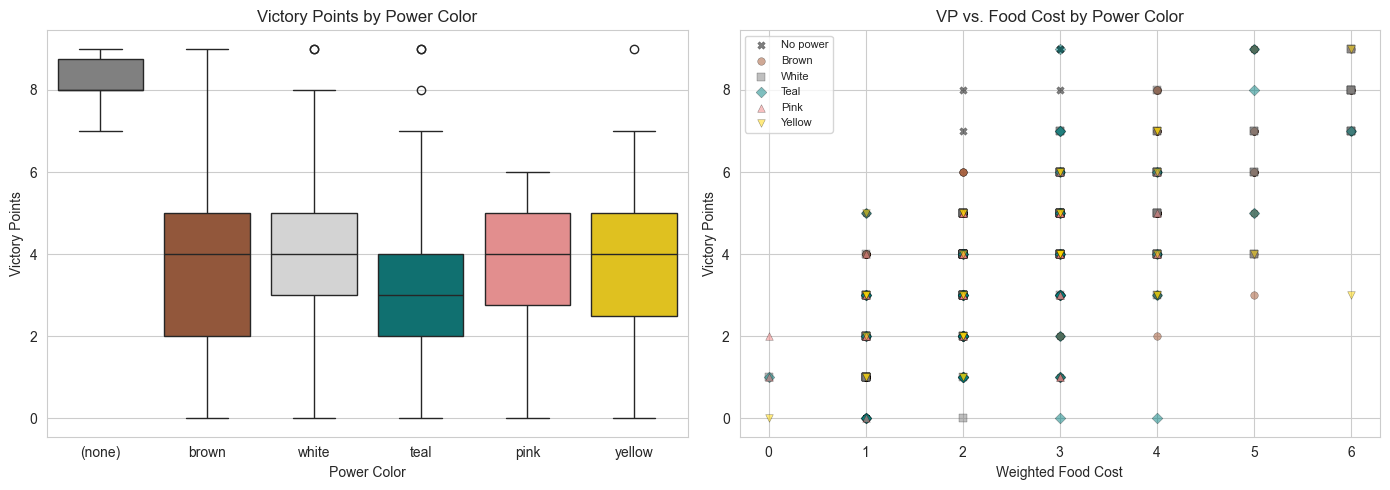

In [5]:
# VP distribution by power color
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: VP by color
color_order = ["(none)", "brown", "white", "teal", "pink", "yellow"]

plot_color = feat_df["color"].fillna("(none)")

sns.boxplot(
    x=plot_color,
    y=feat_df["victory_points"],
    order=color_order,
    ax=axes[0],
    hue=plot_color,
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
        "teal": "teal",
        "pink": "lightcoral",
        "yellow": "gold"
    },
    legend=False,
)

axes[0].set_xlabel("Power Color")
axes[0].set_ylabel("Victory Points")
axes[0].set_title("Victory Points by Power Color")

# VP vs weighted food cost, colored by power
for color_val, marker, c in [
    (np.nan, "X", "black"),
    ("brown", "o", "sienna"),
    ("white", "s", "grey"),
    ("teal", "D", "teal"),
    ("pink", "^", "lightcoral"),
    ("yellow", "v", "gold")
]:  
    if pd.isna(color_val):
        mask = feat_df["color"].isna()
        label = "No power"
    else:
        mask = feat_df["color"] == color_val
        label = color_val.capitalize()
    axes[1].scatter(
        feat_df.loc[mask, "weighted_food_cost"],
        feat_df.loc[mask, "victory_points"],
        marker=marker,
        c=c,
        alpha=0.5,
        s=30,
        label=label,
        edgecolors="k",
        linewidths=0.3
    )

axes[1].set_xlabel("Weighted Food Cost")
axes[1].set_ylabel("Victory Points")
axes[1].set_title("VP vs. Food Cost by Power Color")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../output/vp_by_color_exploration.png", dpi=150, bbox_inches="tight")
plt.show();

In [6]:
# Summary statistics by power color
summary_cols = [
    "victory_points",
    "weighted_food_cost",
    "total_food_cost",
    "egg_limit",
    "bonus_count",
    "habitat_count"
]

color_summary = (
    feat_df
    .groupby(feat_df["color"].fillna("(none)"))
    [summary_cols]
    .agg(["mean", "median", "count"])
)

color_summary.columns = [f"{col}_{stat}" for col, stat in color_summary.columns]
color_summary = color_summary.reindex(["(none)", "brown", "white", "teal", "pink", "yellow"])

print(color_summary.round(2).to_string())

        victory_points_mean  victory_points_median  victory_points_count  weighted_food_cost_mean  weighted_food_cost_median  weighted_food_cost_count  total_food_cost_mean  total_food_cost_median  total_food_cost_count  egg_limit_mean  egg_limit_median  egg_limit_count  bonus_count_mean  bonus_count_median  bonus_count_count  habitat_count_mean  habitat_count_median  habitat_count_count
color                                                                                                                                                                                                                                                                                                                                                                                                 
(none)                 8.17                    8.0                     6                     2.83                        3.0                         6                  2.67                     3.0                      

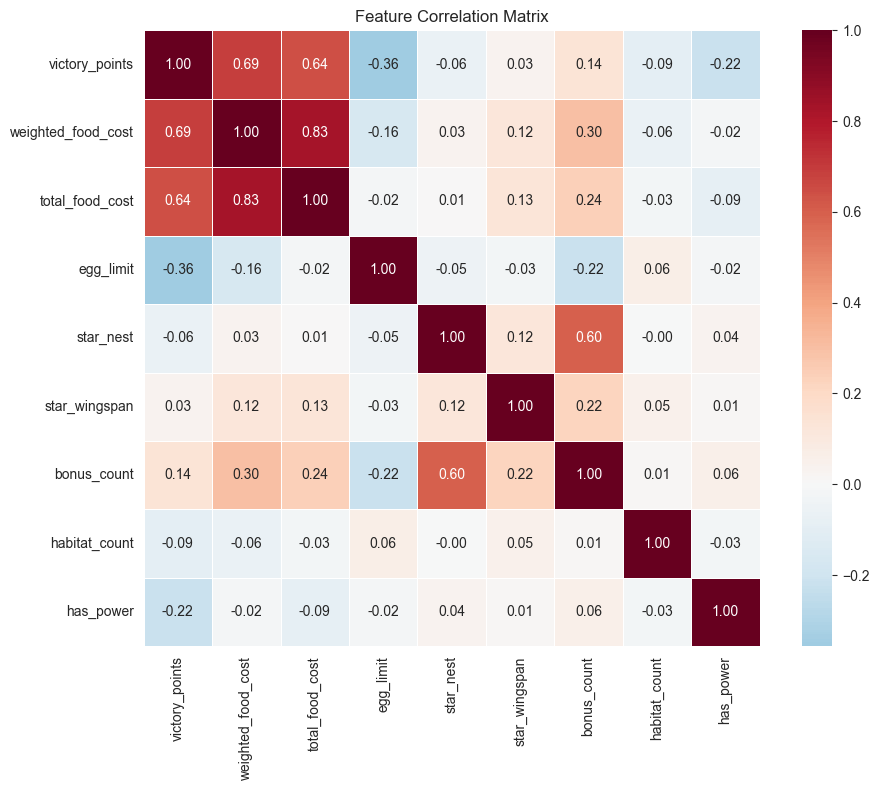

In [7]:
# Correlation matrix of key numeric features
corr_cols = [
    "victory_points",
    "weighted_food_cost",
    "total_food_cost",
    "egg_limit",
    "star_nest",
    "star_wingspan",
    "bonus_count",
    "habitat_count",
    "has_power"
]

corr = feat_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5
)

ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../output/feature_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show();

---
## Stage 1: Baseline Model (Non-Power Attributes)

Regress Victory Points on attributes that are **independent of the bird's power**:
- Weighted food cost (rarity-adjusted)
- Egg limit
- Nest type dummies (reference: ground)
- Star nest and star wingspan indicators
- Bonus card eligibility count
- Habitat count (flexibility of placement)
- Predator cost indicator (the `*` mechanic is part of the power, flagged here)

**Hypothesis:** Higher food cost → higher VP (you pay more, you get more points).
Powerless birds should be well-explained by this model since their VP is their
entire value proposition.

In [8]:
# Stage 1 feature set
stage1_features = [
    "weighted_food_cost",
    "egg_limit",
    "star_nest",
    "nest_none",
    "nest_bowl",
    "nest_cavity",
    "nest_platform",
    "star_wingspan",
    "bonus_count",
    "habitat_count",
    "has_predator_cost",
]

X1 = sm.add_constant(feat_df[stage1_features])
y = feat_df["victory_points"]

model1 = sm.OLS(y, X1).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         victory_points   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     69.35
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.06e-98
Time:                        18:22:58   Log-Likelihood:                -1006.9
No. Observations:                 596   AIC:                             2038.
Df Residuals:                     584   BIC:                             2090.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.7521      0

In [9]:
# How well does Stage 1 explain birds without powers?
powerless_idx = feat_df[feat_df["has_power"] == 0].index
powerless_pred = model1.predict(X1.loc[powerless_idx])
powerless_actual = y.loc[powerless_idx]
powerless_resid = powerless_actual - powerless_pred

print("Stage 1 — Non-powered bird OLS fit:")
print("="*60)
for idx in powerless_idx:
    name = feat_df.loc[idx, "common_name"]
    actual = y.loc[idx]
    pred = model1.predict(X1.loc[[idx]]).iloc[0]
    print(f"  {name:<25} Actual: {actual:.0f}  Predicted: {pred:.1f}  Residual: {actual - pred:+.1f}")

print(f"\n  MAE (non-powered):  {powerless_resid.abs().mean():.2f}")
print(f"  RMSE (non-powered): {np.sqrt((powerless_resid**2).mean()):.2f}")
print(f"\n  MAE (all birds):  {model1.resid.abs().mean():.2f}")
print(f"  RMSE (all birds): {np.sqrt((model1.resid**2).mean()):.2f}")

Stage 1 — Non-powered bird OLS fit:
  American Woodcock         Actual: 9  Predicted: 5.1  Residual: +3.9
  Blue-Winged Warbler       Actual: 8  Predicted: 3.5  Residual: +4.5
  Hooded Warbler            Actual: 7  Predicted: 3.5  Residual: +3.5
  Prothonotary Warbler      Actual: 8  Predicted: 3.8  Residual: +4.2
  Trumpeter Swan            Actual: 9  Predicted: 5.0  Residual: +4.0
  Wild Turkey               Actual: 8  Predicted: 4.7  Residual: +3.3

  MAE (non-powered):  3.89
  RMSE (non-powered): 3.91

  MAE (all birds):  1.02
  RMSE (all birds): 1.31


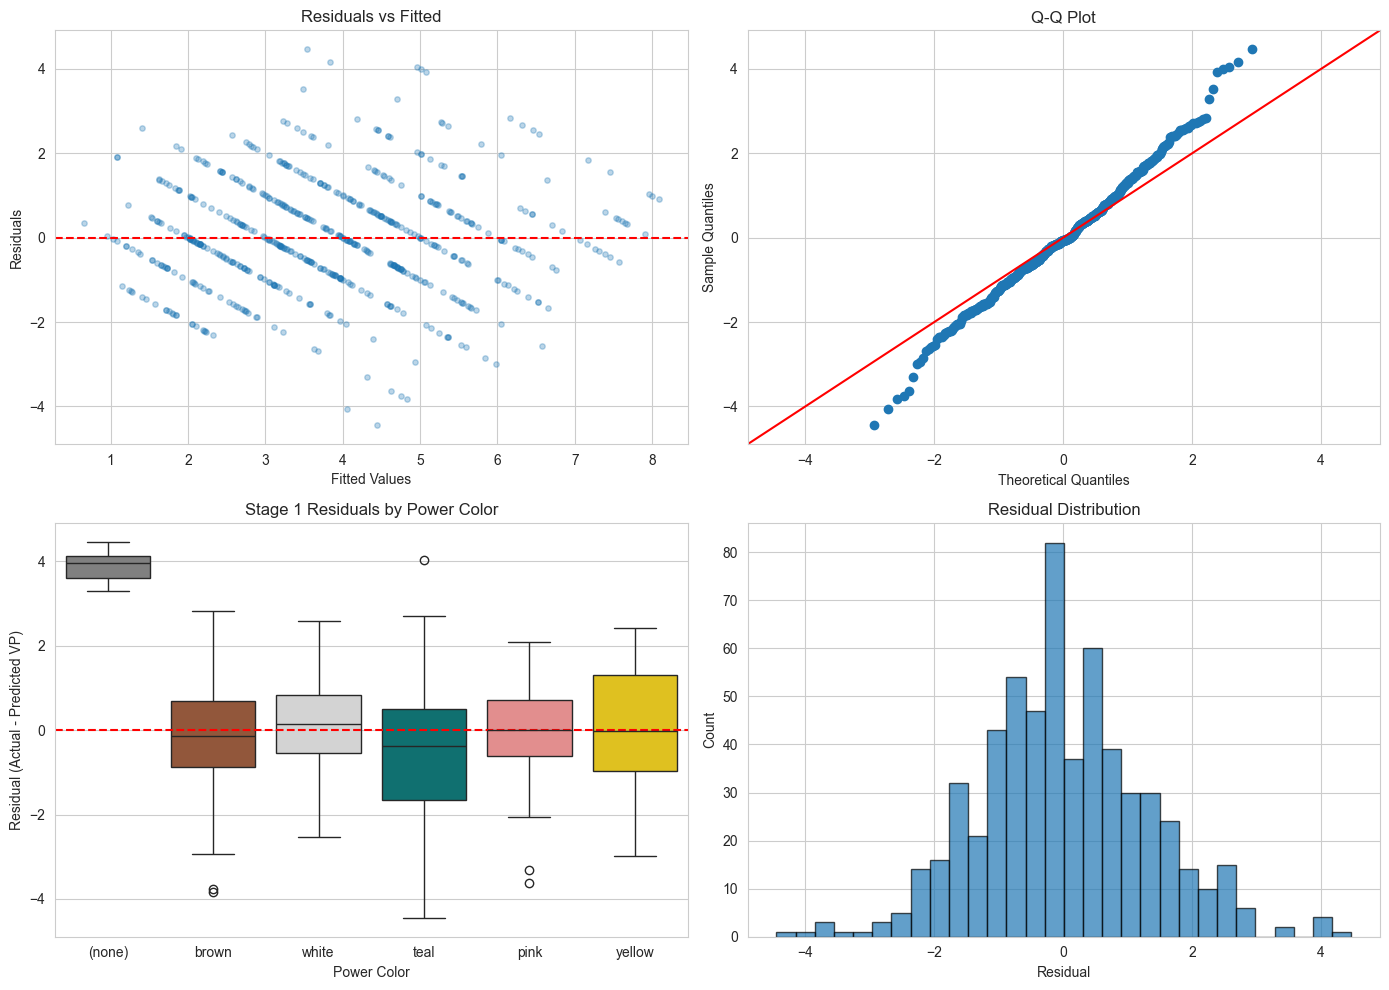


Mean residual by power color (Stage 1):
        mean   std  count
color                    
(none)  3.89  0.43      6
brown  -0.06  1.20    342
white   0.17  1.05    122
teal   -0.45  1.71     51
pink   -0.02  1.25     40
yellow  0.02  1.57     35


In [10]:
# Stage 1 residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs fitted
axes[0, 0].scatter(model1.fittedvalues, model1.resid, alpha=0.3, s=15)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# QQ plot
sm.qqplot(model1.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot")

# Residuals by power color
resid_df = pd.DataFrame(
    {
        "common_name": feat_df['common_name'],
        "residual": model1.resid,
        "color": feat_df["color"].fillna("(none)")
    }
)
color_order = ["(none)", "brown", "white", "teal", "pink", "yellow"]

sns.boxplot(
    data=resid_df,
    x="color",
    y="residual",
    hue="color",
    order=color_order,
    ax=axes[1, 0],
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
        "teal": "teal",
        "pink": "lightcoral",
        "yellow": "gold"
    },
    legend=False,
)

axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Power Color")
axes[1, 0].set_ylabel("Residual (Actual - Predicted VP)")
axes[1, 0].set_title("Stage 1 Residuals by Power Color")

# Histogram of residuals
axes[1, 1].hist(model1.resid, bins=30, edgecolor="black", alpha=0.7)
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("../output/stage1_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# Mean residual by color (should reveal systematic patterns)
print("\nMean residual by power color (Stage 1):")
print(
    resid_df
    .groupby("color")["residual"]
    .agg(["mean", "std", "count"])
    .reindex(color_order)
    .round(2)
)

---
## Stage 2: Adding Power Color

Now add power color dummies. The reference group is **non-powered birds** ("Color" = null).

Each color coefficient represents the average VP adjustment the game designers made for birds of that power color, *controlling for food cost, nest, and other attributes*.

Here we expect to see *negative coefficients* for powers - birds with powers have lower VP, which compensates for the power's value. The magnitude tells us the implicit VP value of each
power-color category. More valuable power colors should have more negative coefficients.

In [11]:
# Stage 2 feature set
stage2_features = stage1_features + [
    "color_brown",
    "color_white",
    "color_teal",
    "color_pink",
    "color_yellow",
]

X2 = sm.add_constant(feat_df[stage2_features])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         victory_points   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     57.11
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.02e-107
Time:                        18:22:59   Log-Likelihood:                -973.69
No. Observations:                 596   AIC:                             1981.
Df Residuals:                     579   BIC:                             2056.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  7.5405      0

In [12]:
# Extract and visualize power color coefficients
color_coefs = pd.DataFrame(
    {
        "color": ["brown", "white", "teal", "pink", "yellow"],
        "coefficient": [model2.params[f"color_{c}"] for c in ["brown", "white", "teal", "pink", "yellow"]],
        "std_err": [model2.bse[f"color_{c}"] for c in ["brown", "white", "teal", "pink", "yellow"]],
        "pvalue": [model2.pvalues[f"color_{c}"] for c in ["brown", "white", "teal", "pink", "yellow"]],
    }
)

color_coefs["ci_lower"] = color_coefs["coefficient"] - 1.96 * color_coefs["std_err"]
color_coefs["ci_upper"] = color_coefs["coefficient"] + 1.96 * color_coefs["std_err"]
color_coefs["significant"] = color_coefs["pvalue"] < 0.05

print("Power Color Coefficients (relative to powerless birds):")
print("="*75)
print(color_coefs.to_string(index=False, float_format="{:.3f}".format))
print("\nInterpretation: A negative coefficient means birds with that power color")
print("have LOWER VP than expected, implying the power's value 'costs' that many VP.")

Power Color Coefficients (relative to powerless birds):
 color  coefficient  std_err  pvalue  ci_lower  ci_upper  significant
 brown       -4.002    0.521   0.000    -5.023    -2.981         True
 white       -3.750    0.530   0.000    -4.790    -2.710         True
  teal       -4.403    0.546   0.000    -5.474    -3.332         True
  pink       -3.964    0.561   0.000    -5.064    -2.864         True
yellow       -3.939    0.562   0.000    -5.040    -2.838         True

Interpretation: A negative coefficient means birds with that power color
have LOWER VP than expected, implying the power's value 'costs' that many VP.


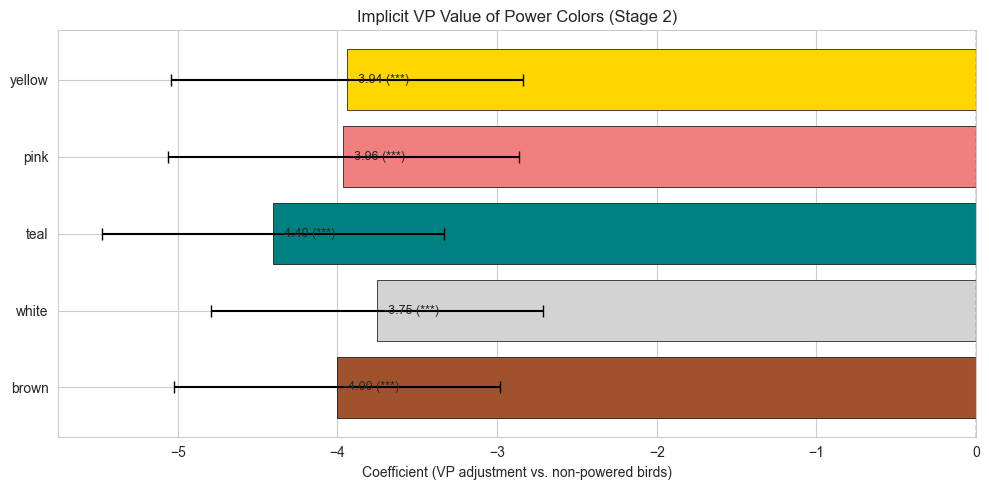

In [13]:
# Visualize power color coefficients with confidence intervals
fig, ax = plt.subplots(figsize=(10, 5))

colors_palette = {
    "brown": "sienna",
    "white": "lightgrey",
    "teal": "teal",
    "pink": "lightcoral",
    "yellow": "gold"
}
bar_colors = [colors_palette[c] for c in color_coefs["color"]]

bars = ax.barh(
    y=color_coefs["color"],
    width=color_coefs["coefficient"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

ax.errorbar(
    x=color_coefs["coefficient"],
    y=color_coefs["color"],
    xerr=(1.96 * color_coefs["std_err"]),
    fmt="none",
    ecolor="black",
    capsize=4,
)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Coefficient (VP adjustment vs. non-powered birds)")
ax.set_title("Implicit VP Value of Power Colors (Stage 2)")

# Add p-value annotations
for i, row in color_coefs.iterrows():
    sig = "***" if row["pvalue"] < 0.001 else "**" if row["pvalue"] < 0.01 else "*" if row["pvalue"] < 0.05 else "ns"
    ax.annotate(
        f"  {row['coefficient']:.2f} ({sig})",
        xy=(row["coefficient"], row["color"]),
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("../output/power_color_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Model comparison: Stage 1 vs Stage 2
print("Model Comparison")
print("="*60)
print(f"{'Metric':<30} {'Stage 1':>12} {'Stage 2':>12}")
print("-"*60)
print(f"{'R-squared':<30} {model1.rsquared:>12.4f} {model2.rsquared:>12.4f}")
print(f"{'Adj. R-squared':<30} {model1.rsquared_adj:>12.4f} {model2.rsquared_adj:>12.4f}")
print(f"{'AIC':<30} {model1.aic:>12.1f} {model2.aic:>12.1f}")
print(f"{'BIC':<30} {model1.bic:>12.1f} {model2.bic:>12.1f}")
print(f"{'RMSE':<30} {np.sqrt(model1.mse_resid):>12.3f} {np.sqrt(model2.mse_resid):>12.3f}")
print(f"{'MAE':<30} {model1.resid.abs().mean():>12.3f} {model2.resid.abs().mean():>12.3f}")
print(f"{'F-statistic':<30} {model1.fvalue:>12.1f} {model2.fvalue:>12.1f}")
print(f"{'Num features':<30} {model1.df_model:>12.0f} {model2.df_model:>12.0f}")

# F-test for the incremental value of power color dummies
f_test = model2.compare_f_test(model1)
print(f"\nF-test (Stage 2 vs Stage 1): F={f_test[0]:.3f}, p={f_test[1]:.4f}")
print(f"Adding power colors {'significantly' if f_test[1] < 0.05 else 'does not significantly'} improve the model.")

Model Comparison
Metric                              Stage 1      Stage 2
------------------------------------------------------------
R-squared                            0.5664       0.6121
Adj. R-squared                       0.5582       0.6014
AIC                                  2037.8       1981.4
BIC                                  2090.5       2056.0
RMSE                                  1.324        1.258
MAE                                   1.016        0.972
F-statistic                            69.4         57.1
Num features                             11           16

F-test (Stage 2 vs Stage 1): F=13.651, p=0.0000
Adding power colors significantly improve the model.


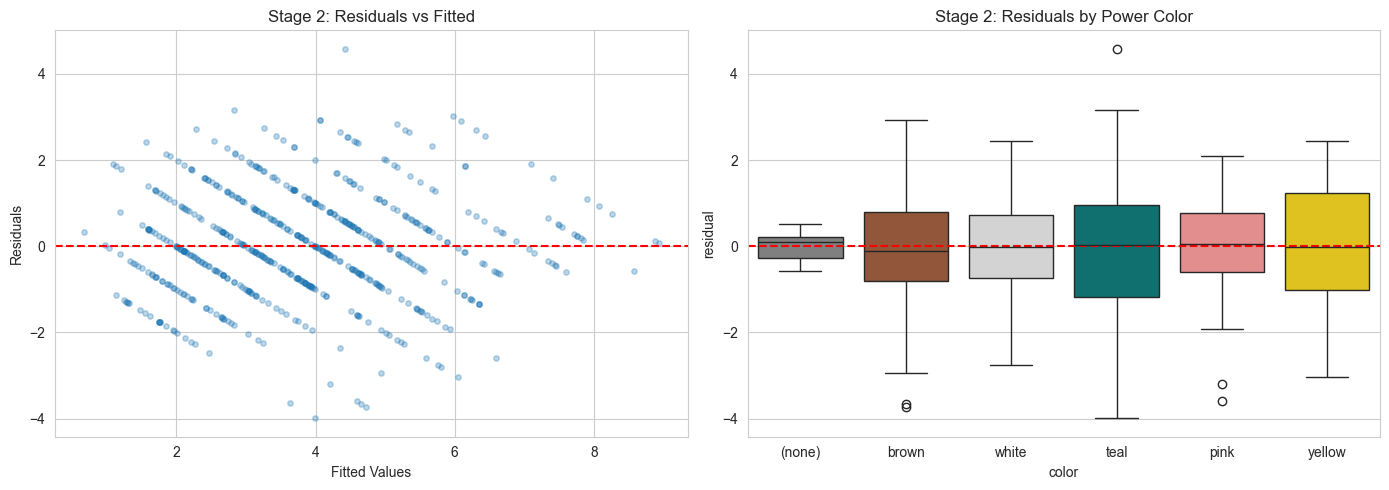


Mean residual by power color (Stage 2):
        mean   std  count
color                    
(none)  -0.0  0.41      6
brown   -0.0  1.20    342
white   -0.0  1.06    122
teal    -0.0  1.72     51
pink    -0.0  1.24     40
yellow  -0.0  1.57     35


In [15]:
# Stage 2 residual diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs fitted
axes[0].scatter(model2.fittedvalues, model2.resid, alpha=0.3, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Stage 2: Residuals vs Fitted")

# Residuals by color
resid2_df = pd.DataFrame({"residual": model2.resid, "color": feat_df["color"].fillna("(none)")})
sns.boxplot(
    data=resid2_df,
    x="color",
    y="residual",
    hue="color",
    order=color_order,
    ax=axes[1],
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
        "teal": "teal",
        "pink": "lightcoral",
        "yellow": "gold"
    }
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Stage 2: Residuals by Power Color")

plt.tight_layout()
plt.savefig("../output/stage2_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMean residual by power color (Stage 2):")
print(resid2_df.groupby("color")["residual"].agg(["mean", "std", "count"]).reindex(color_order).round(2))

In [16]:
# Residual outliers
# Which birds have the impled most valuable powers?
resid_df.sort_values(by='residual', ascending=True).head(10)

,common_name,residual,color
325,Lesser Whitethroat,-4.448930,teal
50,Black Redstart,-4.054258,teal
423,Rainbow Lorikeet,-3.826930,brown
23,Audouin's Gull,-3.757629,brown
501,Spangled Drongo,-3.624053,pink
400,Pheasant Coucal,-3.311298,pink
590,Yellow-Eyed Penguin,-2.986956,yellow
68,Black-Shouldered Kite,-2.935223,brown
179,Dovekie,-2.845812,yellow
579,Willow Warbler,-2.684655,teal


In [17]:
# All Stage 2 coefficients in one clean table
coef_table = pd.DataFrame({
    "coefficient": model2.params,
    "std_err": model2.bse,
    "t_stat": model2.tvalues,
    "p_value": model2.pvalues,
    "ci_lower": model2.conf_int()[0],
    "ci_upper": model2.conf_int()[1],
})
coef_table["significant"] = coef_table["p_value"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
)
print("\nFull Stage 2 Coefficient Table:")
print(coef_table.round(4).to_string())


Full Stage 2 Coefficient Table:
                    coefficient  std_err   t_stat  p_value  ci_lower  ci_upper significant
const                    7.5405   0.6196  12.1701   0.0000    6.3236    8.7575         ***
weighted_food_cost       1.0189   0.0430  23.7125   0.0000    0.9345    1.1032         ***
egg_limit               -0.4598   0.0466  -9.8707   0.0000   -0.5513   -0.3683         ***
star_nest               -0.4999   0.2236  -2.2354   0.0258   -0.9392   -0.0607           *
nest_none               -1.1460   0.5561  -2.0607   0.0398   -2.2382   -0.0538           *
nest_bowl               -0.3194   0.1531  -2.0863   0.0374   -0.6200   -0.0187           *
nest_cavity             -0.3667   0.1537  -2.3862   0.0173   -0.6684   -0.0649           *
nest_platform           -0.3827   0.1673  -2.2881   0.0225   -0.7112   -0.0542           *
star_wingspan           -0.6959   0.4413  -1.5769   0.1154   -1.5626    0.1708            
bonus_count             -0.1076   0.0459  -2.3432   0.019

---
## Stage 3: Power Mechanic Features

Stage 2 showed that all power colors are worth ~4 VP on average. But within each color,
residual std is 1.2–1.8 VP — specific mechanics explain meaningful VP variation.

**Approach:** Parse power text via regex to extract 24 mechanic features:
- 13 binary indicators (gain food, draw cards, lay eggs, tuck, cache, etc.)
- 1 pre-tagged flag from raw data (flocking)
- 5 predator sub-type indicators (look-wingspan, roll-dice, play-on-top, pay-card, other)
- 1 continuous predator success probability (hunt reliability based on card pool or dice math)
- 4 numeric magnitude features (max tuck/egg/draw/food count per activation)

These features capture *what* a power does, complementing the color dummies that capture
*when* it activates. The predator sub-types and success probabilities add nuance to the
74 predator-tagged birds that were previously lumped together.

In [18]:
# Rebuild feature matrix with mechanic features
from importlib import reload
import src.features
reload(src.features)
from src.features import build_feature_matrix, POWER_MECHANIC_FEATURES_LIST

raw = load_bird_data()
feat_df = build_feature_matrix(raw)

print(f"Feature matrix: {feat_df.shape[0]} birds, {feat_df.shape[1]} columns")
print(f"Mechanic features: {len(POWER_MECHANIC_FEATURES_LIST)}")
print(f"\nMechanic feature list:")
for f in POWER_MECHANIC_FEATURES_LIST:
    print(f"  {f:<25} mean={feat_df[f].mean():.3f}  sum={feat_df[f].sum()}")

Feature matrix: 596 birds, 49 columns
Mechanic features: 24

Mechanic feature list:
  mech_gain_food            mean=0.211  sum=126
  mech_draw_card            mean=0.148  sum=88
  mech_lay_egg              mean=0.181  sum=108
  mech_tuck                 mean=0.121  sum=72
  mech_cache                mean=0.111  sum=66
  mech_from_supply          mean=0.252  sum=150
  mech_from_feeder          mean=0.101  sum=60
  mech_reset_feeder         mean=0.040  sum=24
  mech_bonus_card           mean=0.097  sum=58
  mech_play_bird            mean=0.039  sum=23
  mech_repeat_copy          mean=0.017  sum=10
  mech_other_player         mean=0.250  sum=149
  mech_discard_to_gain      mean=0.057  sum=34
  mech_flocking             mean=0.163  sum=97
  pred_look_wingspan        mean=0.020  sum=12
  pred_roll_dice            mean=0.045  sum=27
  pred_play_on_top          mean=0.007  sum=4
  pred_pay_card             mean=0.007  sum=4
  pred_other                mean=0.045  sum=27
  pred_success_prob  

In [19]:
# Mechanic frequency by power color
# Include mech_* binaries (excluding mech_max_*) and pred_* binaries (excluding pred_success_prob)
binary_mechs_list = [
    f for f in POWER_MECHANIC_FEATURES_LIST
    if not f.startswith("mech_max_") and f != "pred_success_prob"
]

color_mech_df = (
    feat_df[feat_df["has_power"] == 1]
    .groupby("color")[binary_mechs_list]
    .sum()
    .T
)
color_mech_df.columns.name = None
color_mech_df = color_mech_df[["brown", "white", "teal", "pink", "yellow"]]
color_mech_df["total"] = color_mech_df.sum(axis=1)

print("Mechanic counts by power color:")
print(color_mech_df.to_string())

Mechanic counts by power color:
                      brown  white  teal  pink  yellow  total
mech_gain_food           97      9     5    15       0    126
mech_draw_card           63     10     9     4       2     88
mech_lay_egg             52     20    13    11      12    108
mech_tuck                51      5     8     4       4     72
mech_cache               46      3     8     3       6     66
mech_from_supply        105     12    17     9       7    150
mech_from_feeder         46      2     1    11       0     60
mech_reset_feeder        17      2     4     0       1     24
mech_bonus_card           0     51     1     1       5     58
mech_play_bird            3     17     3     0       0     23
mech_repeat_copy          9      0     0     0       1     10
mech_other_player        82     19     5    40       3    149
mech_discard_to_gain     28      6     0     0       0     34
mech_flocking            67      8    15     3       4     97
pred_look_wingspan       12      0    

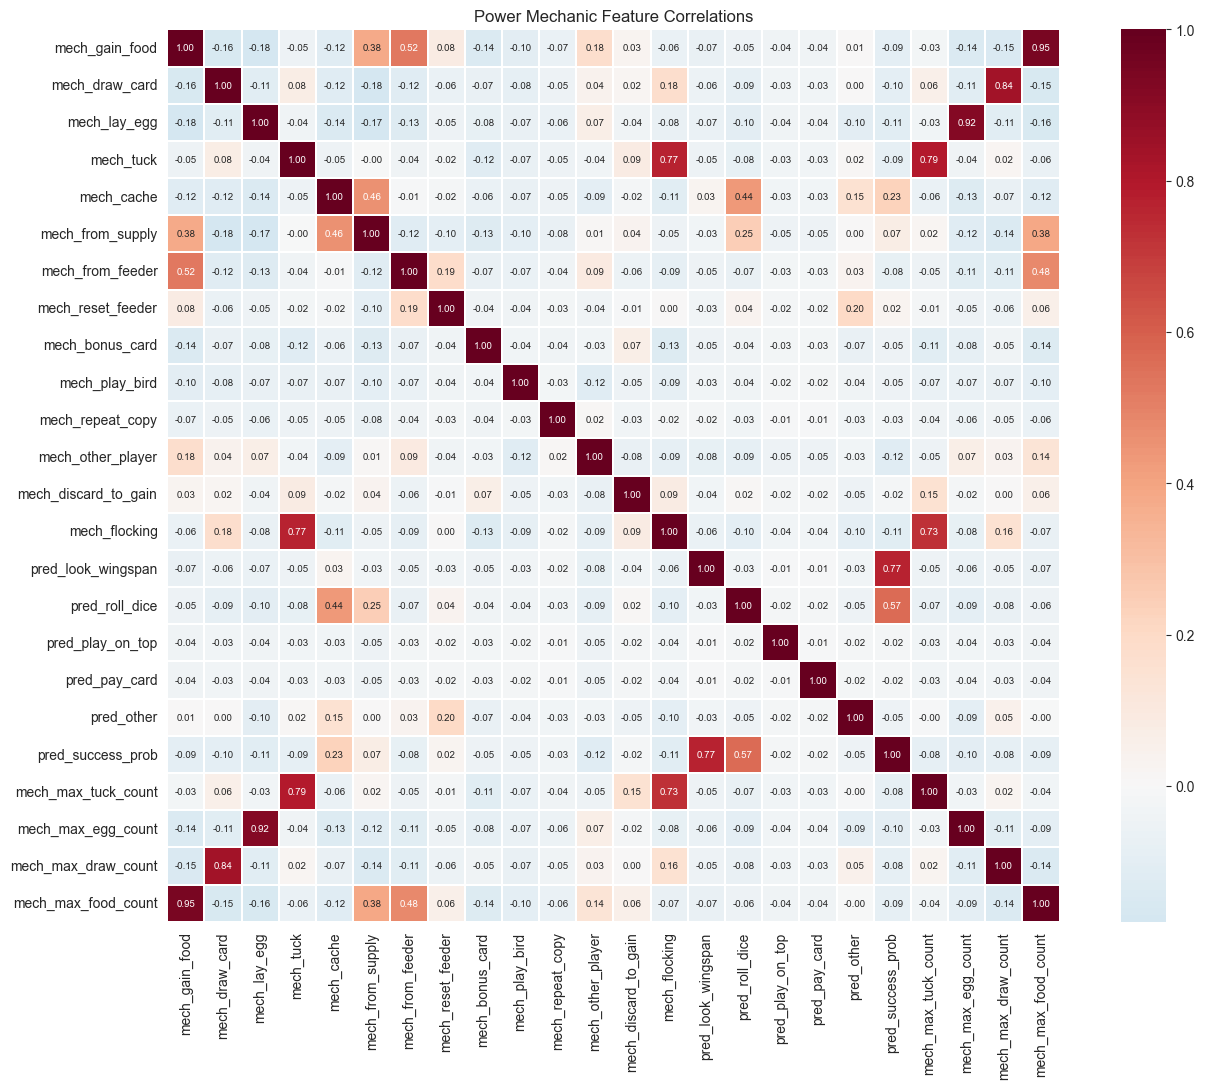

In [20]:
# Mechanic feature correlation heatmap
mech_corr = feat_df[POWER_MECHANIC_FEATURES_LIST].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    mech_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 7},
)
ax.set_title("Power Mechanic Feature Correlations")
plt.tight_layout()
plt.savefig(
    "../output/mechanic_correlation_matrix.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

Predator sub-type summary:
               count  mean_vp  mean_prob  min_prob  max_prob
sub_type                                                    
look_wingspan     12    5.167      0.656     0.349     0.800
other             27    4.444      0.000     0.000     0.000
pay_card           4    6.000      0.000     0.000     0.000
play_on_top        4    4.000      0.000     0.000     0.000
roll_dice         27    4.630      0.332     0.167     0.598

Total predator-tagged birds: 74


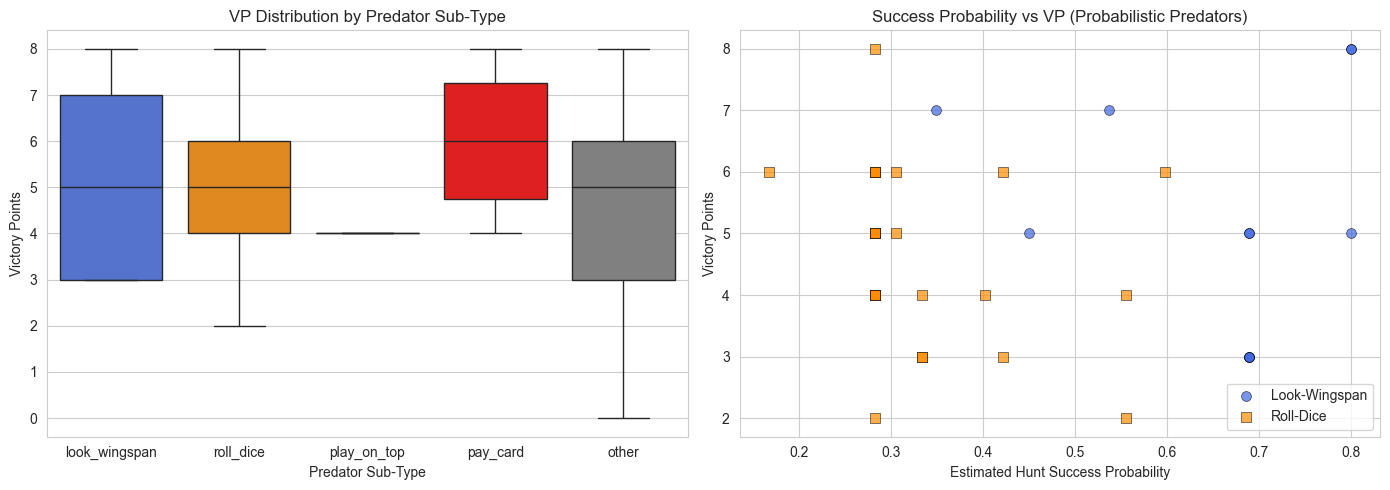


Example predator birds by sub-type:

  LOOK_WINGSPAN (12 birds):
    Great Horned Owl             VP=8  P=0.800
      Look at a [card] from the deck. If less than 100cm, tuck it behind this bird. If not, disc
    Golden Eagle                 VP=8  P=0.800
      Look at a [card] from the deck. If less than 100cm, tuck it behind this bird. If not, disc
    Peregrine Falcon             VP=5  P=0.800
      Look at a [card] from the deck. If less than 100cm, tuck it behind this bird. If not, disc

  ROLL_DICE (27 birds):
    Philippine Eagle             VP=6  P=0.598
      Roll all 5 [die]. You may reroll any number of [die], up to 2 times. If at least 3 [rodent
    Forest Owlet                 VP=4  P=0.556
      Choose any 2 [die]. Roll them up to 3 times. Each time, if you roll at least 1 [invertebra
    Purple Heron                 VP=2  P=0.556
      Choose any 2 [die]. Roll them up to 3 times. Each time, if you roll at least 1 [invertebra

  PLAY_ON_TOP (4 birds):
    Common Buzzard 

In [21]:
# Predator sub-type detail: birds grouped by sub-type with success probabilities
pred_subtypes_list = [
    "pred_look_wingspan",
    "pred_roll_dice",
    "pred_play_on_top",
    "pred_pay_card",
    "pred_other",
]

pred_mask = feat_df[pred_subtypes_list].any(axis=1)
pred_birds_df = feat_df[pred_mask][[
    "common_name",
    "victory_points",
    "pred_success_prob",
    "power_text",
] + pred_subtypes_list].copy()

# Assign sub-type label
pred_birds_df["sub_type"] = "unknown"
for st in pred_subtypes_list:
    pred_birds_df.loc[pred_birds_df[st] == 1, "sub_type"] = st.replace("pred_", "")

# Summary table by sub-type
subtype_summary_df = (
    pred_birds_df
    .groupby("sub_type")
    .agg(
        count=("common_name", "size"),
        mean_vp=("victory_points", "mean"),
        mean_prob=("pred_success_prob", "mean"),
        min_prob=("pred_success_prob", "min"),
        max_prob=("pred_success_prob", "max"),
    )
    .round(3)
)
print("Predator sub-type summary:")
print(subtype_summary_df.to_string())
print(f"\nTotal predator-tagged birds: {len(pred_birds_df)}")

# Scatter plot: pred_success_prob vs victory_points for look-wingspan and roll-dice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: all sub-types VP distribution
subtype_order_list = ["look_wingspan", "roll_dice", "play_on_top", "pay_card", "other"]
subtype_colors_dict = {
    "look_wingspan": "royalblue",
    "roll_dice": "darkorange",
    "play_on_top": "green",
    "pay_card": "red",
    "other": "grey",
}
sns.boxplot(
    data=pred_birds_df,
    x="sub_type",
    y="victory_points",
    hue="sub_type",
    order=subtype_order_list,
    palette=subtype_colors_dict,
    ax=axes[0],
    legend=False,
)
axes[0].set_xlabel("Predator Sub-Type")
axes[0].set_ylabel("Victory Points")
axes[0].set_title("VP Distribution by Predator Sub-Type")

# Right panel: success probability vs VP for look-wingspan and roll-dice
for st, color, marker, label in [
    ("look_wingspan", "royalblue", "o", "Look-Wingspan"),
    ("roll_dice", "darkorange", "s", "Roll-Dice"),
]:
    mask = pred_birds_df["sub_type"] == st
    axes[1].scatter(
        pred_birds_df.loc[mask, "pred_success_prob"],
        pred_birds_df.loc[mask, "victory_points"],
        c=color,
        marker=marker,
        s=50,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.5,
        label=label,
    )

axes[1].set_xlabel("Estimated Hunt Success Probability")
axes[1].set_ylabel("Victory Points")
axes[1].set_title("Success Probability vs VP (Probabilistic Predators)")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    "../output/predator_subtype_detail.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

# Show a few example birds per sub-type
print("\nExample predator birds by sub-type:")
for st in subtype_order_list:
    st_birds = pred_birds_df[pred_birds_df["sub_type"] == st].sort_values(
        "pred_success_prob",
        ascending=False,
    )
    print(f"\n  {st.upper()} ({len(st_birds)} birds):")
    for _, row in st_birds.head(3).iterrows():
        prob_str = f"P={row['pred_success_prob']:.3f}" if row["pred_success_prob"] > 0 else "P=n/a"
        print(f"    {row['common_name']:<28} VP={row['victory_points']:.0f}  {prob_str}")
        print(f"      {row['power_text'][:90]}")

### Stage 3a: Main Effects Model

Add all 24 mechanic features to the Stage 2 model. These include 13 binary regex indicators,
1 flocking flag, 5 predator sub-type dummies, 1 continuous predator success probability,
and 4 numeric magnitude features.

The color dummies now capture the *residual* value of power color after accounting for
specific mechanics. If mechanics fully explain within-color variation, the color
coefficients should shrink toward zero (or become insignificant).

In [22]:
# Stage 3 feature set: Stage 2 features + all mechanic features
stage3_features = stage2_features + POWER_MECHANIC_FEATURES_LIST

X3 = sm.add_constant(feat_df[stage3_features])
y = feat_df["victory_points"]

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:         victory_points   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     27.38
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.94e-104
Time:                        18:23:01   Log-Likelihood:                -936.51
No. Observations:                 596   AIC:                             1953.
Df Residuals:                     556   BIC:                             2129.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    7.1733 

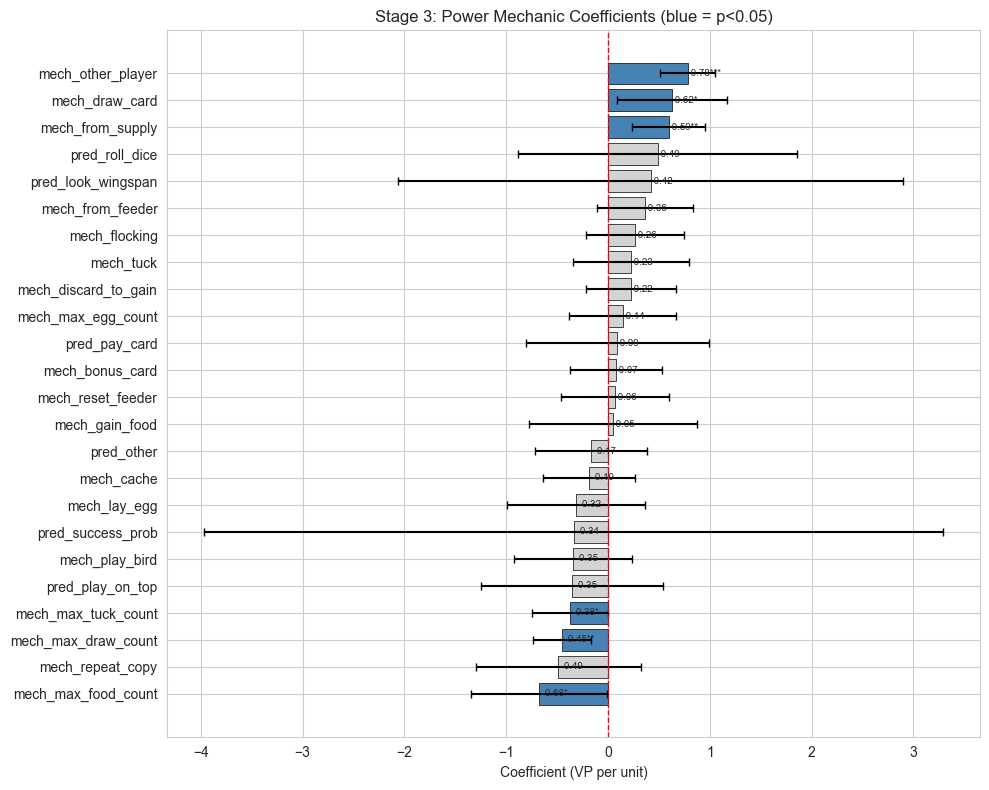

In [23]:
# Stage 3 mechanic coefficient plot
mech_coefs_df = pd.DataFrame({
    "feature": POWER_MECHANIC_FEATURES_LIST,
    "coefficient": [model3.params[f] for f in POWER_MECHANIC_FEATURES_LIST],
    "std_err": [model3.bse[f] for f in POWER_MECHANIC_FEATURES_LIST],
    "pvalue": [model3.pvalues[f] for f in POWER_MECHANIC_FEATURES_LIST],
})
mech_coefs_df["ci_lower"] = mech_coefs_df["coefficient"] - 1.96 * mech_coefs_df["std_err"]
mech_coefs_df["ci_upper"] = mech_coefs_df["coefficient"] + 1.96 * mech_coefs_df["std_err"]
mech_coefs_df["sig"] = mech_coefs_df["pvalue"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
)
mech_coefs_df = mech_coefs_df.sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors_list = [
    "steelblue" if p < 0.05 else "lightgrey"
    for p in mech_coefs_df["pvalue"]
]
ax.barh(
    y=mech_coefs_df["feature"],
    width=mech_coefs_df["coefficient"],
    color=bar_colors_list,
    edgecolor="black",
    linewidth=0.5,
)
ax.errorbar(
    x=mech_coefs_df["coefficient"],
    y=mech_coefs_df["feature"],
    xerr=1.96 * mech_coefs_df["std_err"],
    fmt="none",
    ecolor="black",
    capsize=3,
)
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Coefficient (VP per unit)")
ax.set_title("Stage 3: Power Mechanic Coefficients (blue = p<0.05)")

for _, row in mech_coefs_df.iterrows():
    ax.annotate(
        f" {row['coefficient']:.2f}{row['sig']}",
        xy=(row["coefficient"], row["feature"]),
        va="center",
        fontsize=7,
    )

plt.tight_layout()
plt.savefig(
    "../output/stage3_mechanic_coefficients.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [24]:
# Model comparison: Stages 1 vs 2 vs 3
print("Model Comparison Across All Stages")
print("=" * 70)
print(f"{'Metric':<30} {'Stage 1':>12} {'Stage 2':>12} {'Stage 3':>12}")
print("-" * 70)
for label, m1_val, m2_val, m3_val in [
    ("R-squared", model1.rsquared, model2.rsquared, model3.rsquared),
    ("Adj. R-squared", model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj),
    ("AIC", model1.aic, model2.aic, model3.aic),
    ("BIC", model1.bic, model2.bic, model3.bic),
    ("RMSE", np.sqrt(model1.mse_resid), np.sqrt(model2.mse_resid), np.sqrt(model3.mse_resid)),
    ("MAE", model1.resid.abs().mean(), model2.resid.abs().mean(), model3.resid.abs().mean()),
    ("Num features", model1.df_model, model2.df_model, model3.df_model),
]:
    if label == "Num features":
        print(f"{label:<30} {m1_val:>12.0f} {m2_val:>12.0f} {m3_val:>12.0f}")
    else:
        print(f"{label:<30} {m1_val:>12.4f} {m2_val:>12.4f} {m3_val:>12.4f}")

# F-test: Stage 3 vs Stage 2
f_test_3v2 = model3.compare_f_test(model2)
print(f"\nF-test (Stage 3 vs Stage 2): F={f_test_3v2[0]:.3f}, p={f_test_3v2[1]:.6f}")
print(f"Adding mechanic features {'significantly' if f_test_3v2[1] < 0.05 else 'does not significantly'} improve the model.")

Model Comparison Across All Stages
Metric                              Stage 1      Stage 2      Stage 3
----------------------------------------------------------------------
R-squared                            0.5664       0.6121       0.6576
Adj. R-squared                       0.5582       0.6014       0.6336
AIC                               2037.7895    1981.3720    1953.0290
BIC                               2090.4724    2056.0061    2128.6387
RMSE                                 1.3240       1.2576       1.2058
MAE                                  1.0156       0.9723       0.8968
Num features                             11           16           39

F-test (Stage 3 vs Stage 2): F=3.212, p=0.000001
Adding mechanic features significantly improve the model.


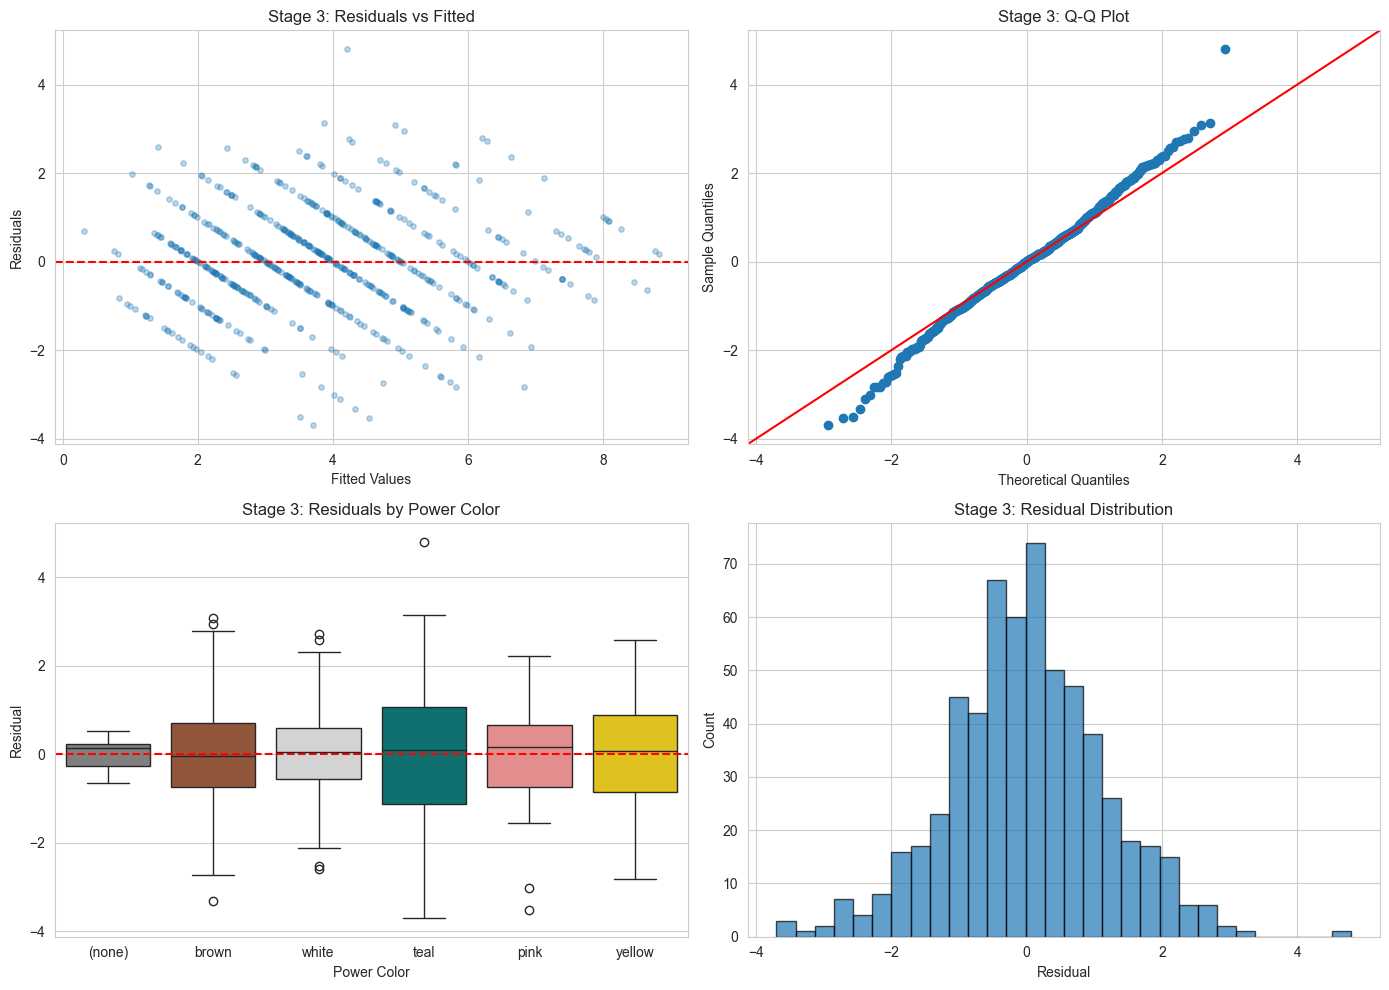


Residual std by color (Stage 2 → Stage 3):
        stage2_std  stage3_std  improvement
(none)       0.408       0.436       -0.028
brown        1.198       1.086        0.112
white        1.056       0.995        0.061
teal         1.716       1.739       -0.023
pink         1.239       1.207        0.031
yellow       1.567       1.505        0.062


In [25]:
# Stage 3 residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs fitted
axes[0, 0].scatter(
    model3.fittedvalues,
    model3.resid,
    alpha=0.3,
    s=15,
)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Stage 3: Residuals vs Fitted")

# QQ plot
sm.qqplot(model3.resid, line="45", ax=axes[0, 1])
axes[0, 1].set_title("Stage 3: Q-Q Plot")

# Residuals by color
resid3_df = pd.DataFrame({
    "residual": model3.resid,
    "color": feat_df["color"].fillna("(none)"),
})
color_order = ["(none)", "brown", "white", "teal", "pink", "yellow"]

sns.boxplot(
    data=resid3_df,
    x="color",
    y="residual",
    hue="color",
    order=color_order,
    ax=axes[1, 0],
    palette={
        "(none)": "grey",
        "brown": "sienna",
        "white": "lightgrey",
        "teal": "teal",
        "pink": "lightcoral",
        "yellow": "gold",
    },
    legend=False,
)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Power Color")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("Stage 3: Residuals by Power Color")

# Histogram of residuals
axes[1, 1].hist(
    model3.resid,
    bins=30,
    edgecolor="black",
    alpha=0.7,
)
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Stage 3: Residual Distribution")

plt.tight_layout()
plt.savefig(
    "../output/stage3_residual_diagnostics.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("\nResidual std by color (Stage 2 → Stage 3):")
resid2_compare_df = pd.DataFrame({
    "stage2_std": pd.DataFrame({"r": model2.resid, "c": feat_df["color"].fillna("(none)")}).groupby("c")["r"].std(),
    "stage3_std": resid3_df.groupby("color")["residual"].std(),
})
resid2_compare_df["improvement"] = resid2_compare_df["stage2_std"] - resid2_compare_df["stage3_std"]
print(resid2_compare_df.reindex(color_order).round(3))

In [26]:
# VIF check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data_df = X3.drop(columns=["const"])
vif_results_list = []
for i, col in enumerate(vif_data_df.columns):
    vif_val = variance_inflation_factor(vif_data_df.values, i)
    vif_results_list.append({"feature": col, "VIF": vif_val})

vif_df = pd.DataFrame(vif_results_list).sort_values("VIF", ascending=False)
print("Variance Inflation Factors (VIF > 5 suggests multicollinearity):")
print(vif_df.to_string(index=False, float_format="{:.2f}".format))

Variance Inflation Factors (VIF > 5 suggests multicollinearity):
             feature   VIF
       pred_pay_card   inf
    pred_play_on_top   inf
   has_predator_cost   inf
         bonus_count 37.35
         color_brown 25.21
   pred_success_prob 20.32
      mech_gain_food 15.26
  pred_look_wingspan 13.22
 mech_max_food_count 12.90
         color_white  9.97
      pred_roll_dice  9.06
        mech_lay_egg  8.91
  mech_max_egg_count  8.30
           egg_limit  7.99
  weighted_food_cost  6.26
       habitat_count  5.70
          color_teal  4.70
          color_pink  4.62
      mech_draw_card  4.57
           mech_tuck  4.18
 mech_max_draw_count  4.17
       mech_flocking  4.00
    mech_from_supply  3.53
        color_yellow  3.51
 mech_max_tuck_count  3.47
          mech_cache  2.41
    mech_from_feeder  2.41
           star_nest  2.39
       nest_platform  2.16
         nest_cavity  2.16
           nest_bowl  2.14
     mech_bonus_card  2.11
   mech_other_player  1.92
          pred_ot

C:\Users\User\Projects\wingspan_cards\.venv_wingspan\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [27]:
# Over- and under-valued birds (largest Stage 3 residuals)
resid3_full_df = pd.DataFrame({
    "common_name": feat_df["common_name"],
    "color": feat_df["color"].fillna("(none)"),
    "victory_points": feat_df["victory_points"],
    "fitted": model3.fittedvalues,
    "residual": model3.resid,
    "power_text": feat_df["power_text"].fillna("(no power)"),
})

print("Top 10 UNDER-valued birds (model predicts higher VP than actual):")
print("These birds have more power than their VP suggests.\n")
under_df = resid3_full_df.nsmallest(10, "residual")
for _, row in under_df.iterrows():
    print(f"  {row['common_name']:<28} VP={row['victory_points']:.0f}  Pred={row['fitted']:.1f}  Resid={row['residual']:+.1f}  ({row['color']})")
    print(f"    {row['power_text'][:100]}")
    print()

print("\nTop 10 OVER-valued birds (model predicts lower VP than actual):")
print("These birds have less power than their VP suggests.\n")
over_df = resid3_full_df.nlargest(10, "residual")
for _, row in over_df.iterrows():
    print(f"  {row['common_name']:<28} VP={row['victory_points']:.0f}  Pred={row['fitted']:.1f}  Resid={row['residual']:+.1f}  ({row['color']})")
    print(f"    {row['power_text'][:100]}")
    print()

Top 10 UNDER-valued birds (model predicts higher VP than actual):
These birds have more power than their VP suggests.

  Lesser Whitethroat           VP=0  Pred=3.7  Resid=-3.7  (teal)
    Choose a habitat with no [egg]. Lay 1 [egg] on each bird in that habitat.

  Spangled Drongo              VP=1  Pred=4.5  Resid=-3.5  (pink)
    When another player gains [nectar], gain 1 [nectar] from the supply.

  Black Redstart               VP=0  Pred=3.5  Resid=-3.5  (teal)
    Choose a habitat with no [egg]. Lay 1 [egg] on each bird in that habitat.

  Audouin's Gull               VP=1  Pred=4.3  Resid=-3.3  (brown)
    Draw 2 [card] from the deck. Tuck 1 behind this bird and keep the other.

  Willow Warbler               VP=1  Pred=4.1  Resid=-3.1  (teal)
    Choose 1 other player. For each action cube on their [forest], tuck 1 [card] from the deck behind th

  Pheasant Coucal              VP=1  Pred=4.0  Resid=-3.0  (pink)
    When another player takes the "lay eggs" action, lay 1 [egg] on 

In [28]:
# Full Stage 3 coefficient table
coef3_table_df = pd.DataFrame({
    "coefficient": model3.params,
    "std_err": model3.bse,
    "t_stat": model3.tvalues,
    "p_value": model3.pvalues,
    "ci_lower": model3.conf_int()[0],
    "ci_upper": model3.conf_int()[1],
})
coef3_table_df["significant"] = coef3_table_df["p_value"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
)
print("\nFull Stage 3 Coefficient Table:")
print(coef3_table_df.round(4).to_string())


Full Stage 3 Coefficient Table:
                      coefficient  std_err   t_stat  p_value  ci_lower  ci_upper significant
const                      7.1733   0.6100  11.7603   0.0000    5.9752    8.3714         ***
weighted_food_cost         1.0232   0.0429  23.8294   0.0000    0.9389    1.1076         ***
egg_limit                 -0.3975   0.0479  -8.2948   0.0000   -0.4917   -0.3034         ***
star_nest                 -0.4147   0.2264  -1.8320   0.0675   -0.8593    0.0299            
nest_none                 -0.7671   0.5500  -1.3947   0.1637   -1.8474    0.3133            
nest_bowl                 -0.2335   0.1550  -1.5063   0.1326   -0.5380    0.0710            
nest_cavity               -0.2215   0.1571  -1.4099   0.1591   -0.5301    0.0871            
nest_platform             -0.3679   0.1684  -2.1847   0.0293   -0.6988   -0.0371           *
star_wingspan             -0.6065   0.4442  -1.3653   0.1727   -1.4790    0.2661            
bonus_count               -0.0922   0

---
## Summary

**Three-stage regression results:**

| Stage | Features | R² | What it captures |
|-------|----------|-----|------------------|
| 1 | Non-power attributes (food cost, nest, wingspan, etc.) | 0.566 | VP-cost tradeoff |
| 2 | + Power color dummies | 0.612 | Average value of having a power (~4 VP) |
| 3 | + 24 mechanic features (incl. predator sub-types + success prob) | 0.658 | Within-color variation by specific mechanic |

**Key findings from Stage 3:**
- Examine which mechanics have significant positive/negative coefficients
- Check whether color coefficients shrink once mechanics are controlled for
- Predator sub-types and success probability capture the nuance among 74 predator-tagged birds
- Review over/under-valued birds for patterns the model misses
- VIF values flag any multicollinearity concerns

**Limitations & next steps:**
- Regex parsing captures *presence* of mechanics but not full context (e.g., conditional
  triggers, scaling with board state)
- Activation frequency differences across colors are captured by color dummies, not by
  mechanic features directly
- Interaction terms (mechanic × color) could capture color-specific mechanic value